In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from tasks import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)
import matplotlib as mpl

# Global plotting style for manuscript figures
mpl.rcParams.update({
    "font.family": "Arial",          # or "Helvetica" if available
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

In [3]:
task = mackey_glass(Npoints=1000)

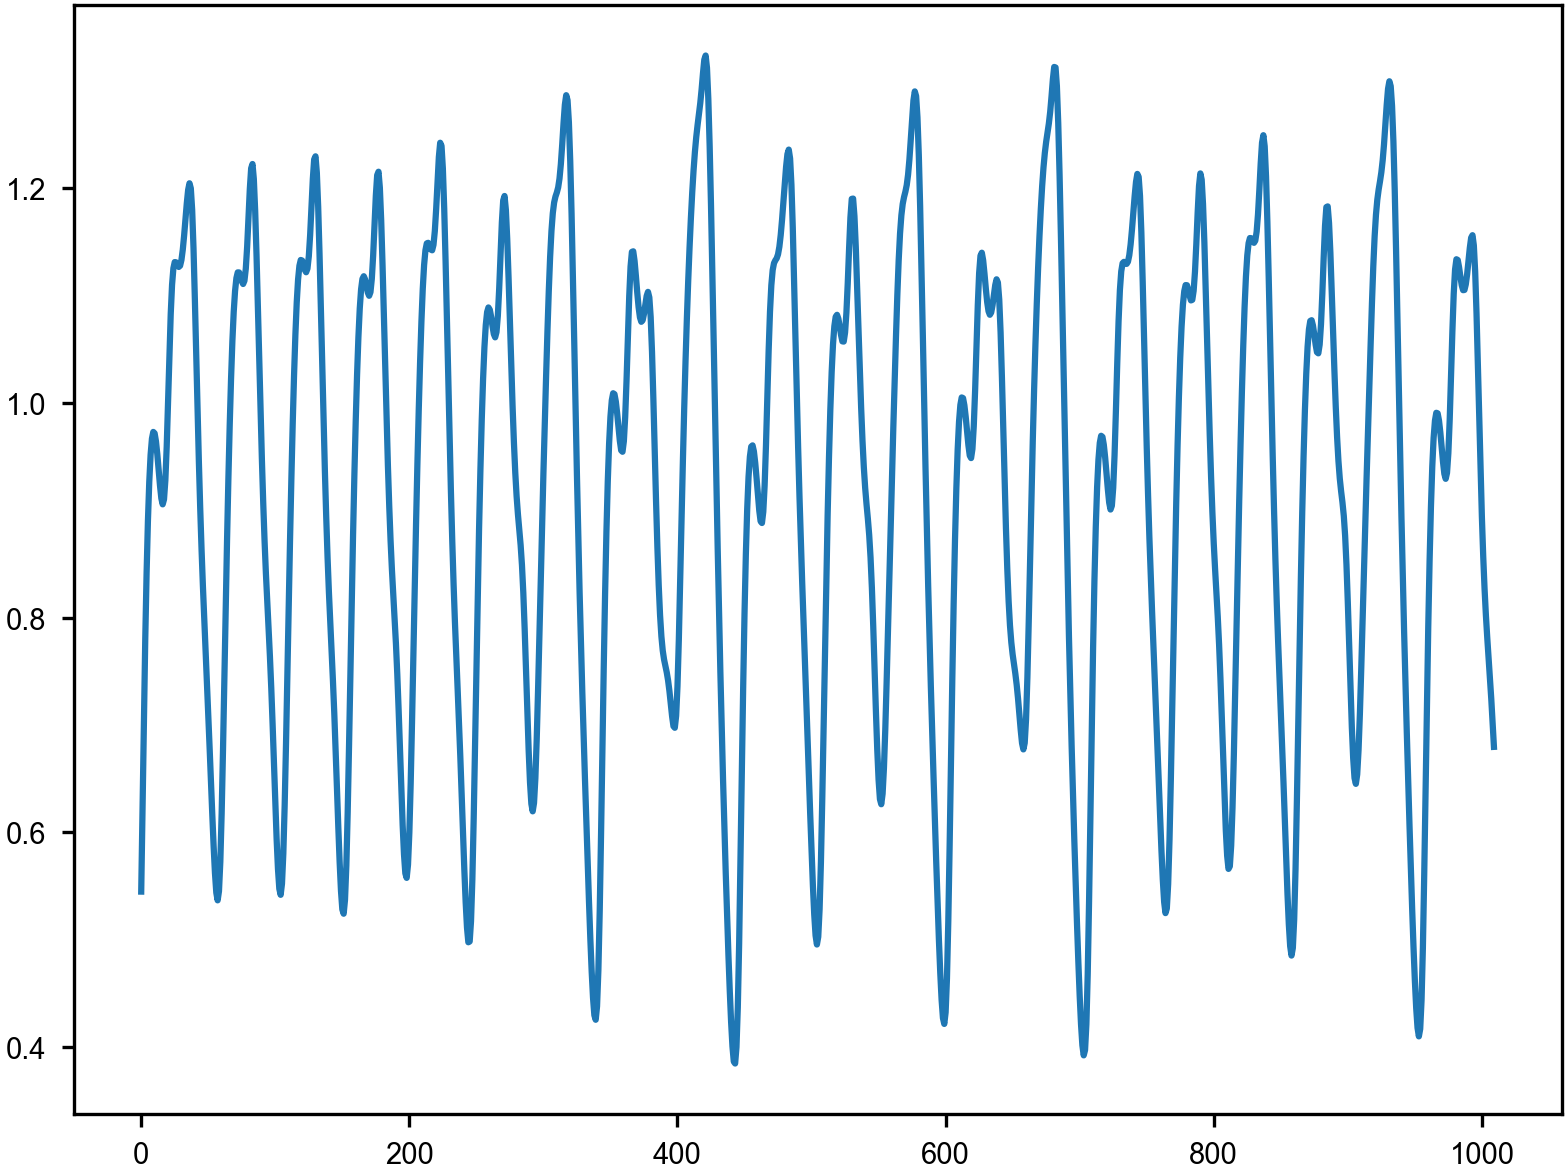

In [5]:
plt.plot(task[:])

In [7]:
N = 4
A, B = make_esn_weights(
    N,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,)

X = esn_dynamics(task, A, B)
# Generate ESN reservoir states for full time series
X.shape

(1010, 4)

In [9]:
Nfading = 10
Ntraining = 790
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau

NRMSE: 0.16729915407600143


Text(0.5, 1.0, 'BTC Prediction by ESN')

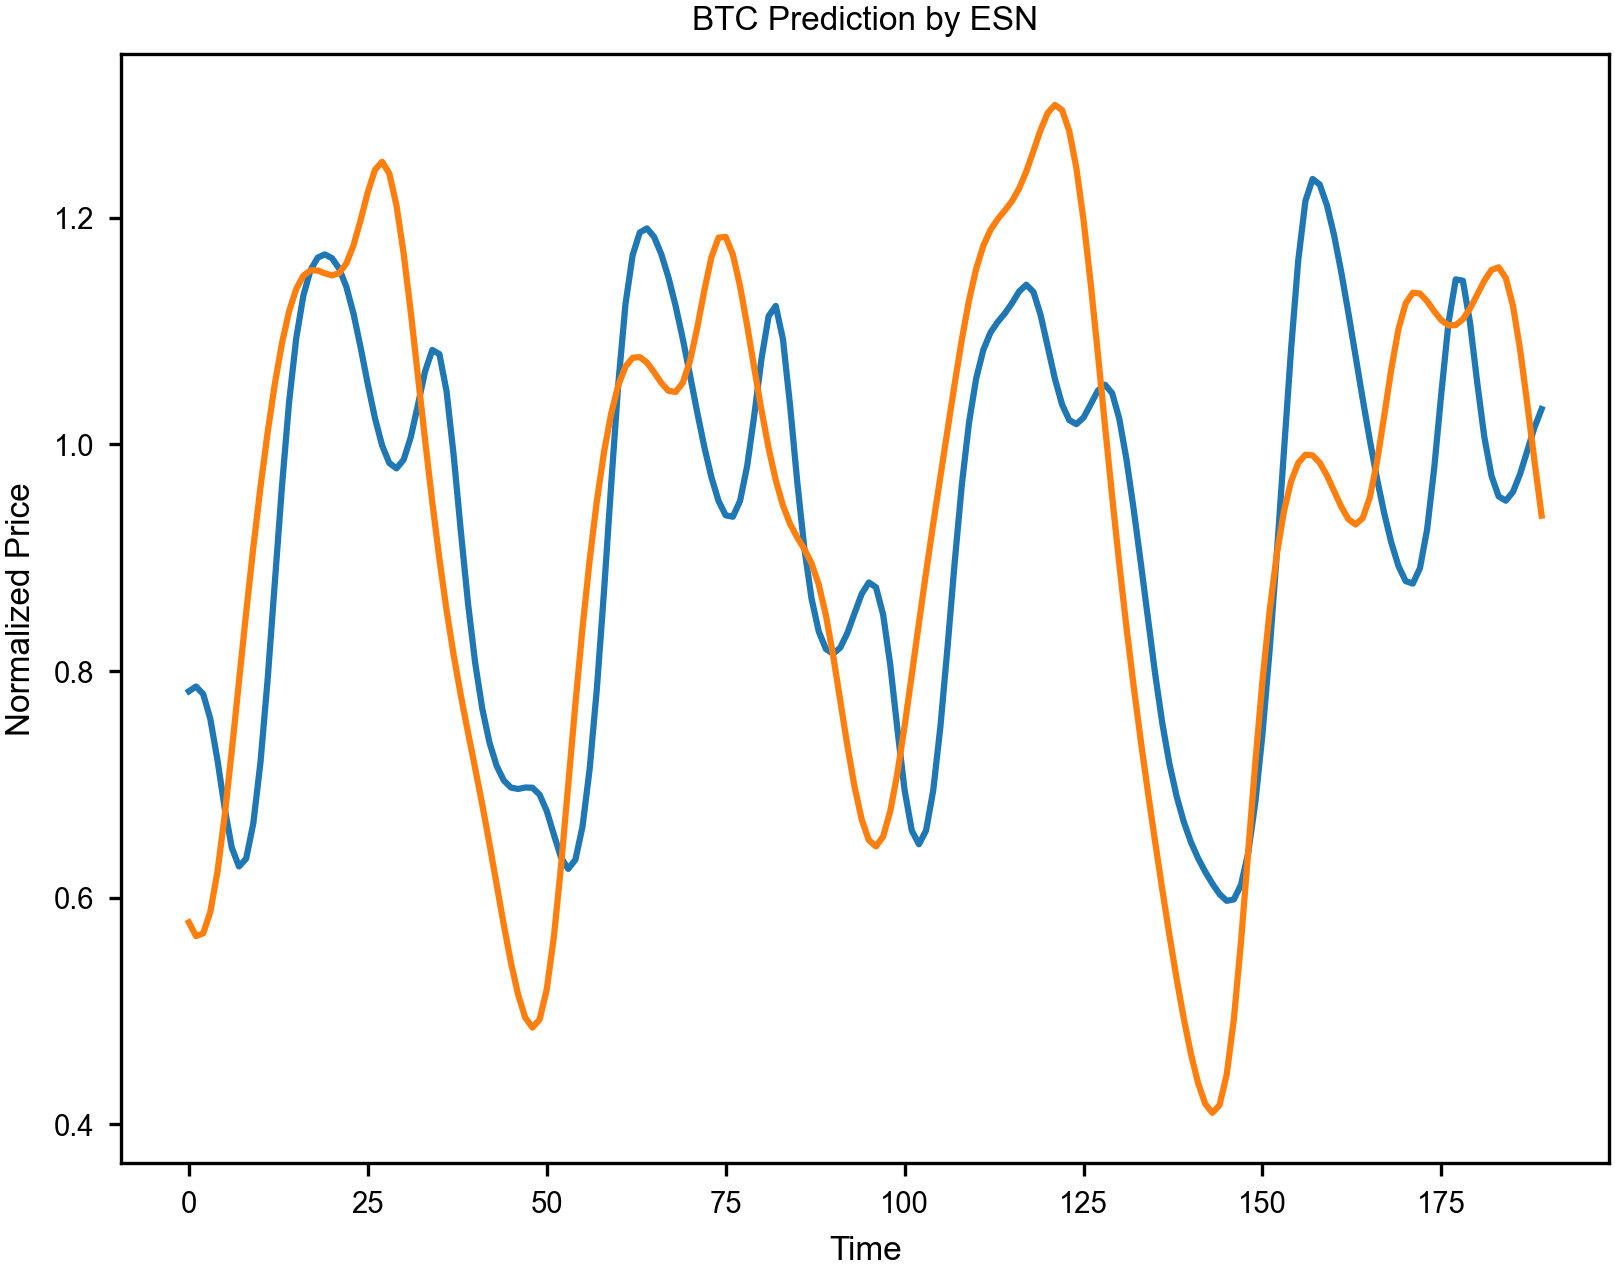

In [11]:
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = task[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")

Quantum Performance

In [14]:
df = pd.read_csv("MG_omega0.16_rep10.csv")
X = extract_delayed_single_column(df, 'PQ-10', N=4, repeat_steps=10)
X.shape

(1000, 4)

Pick any reservoir here, we show the

NRMSE: 0.164463988477245


Text(0.5, 1.0, 'BTC Prediction by ESN')

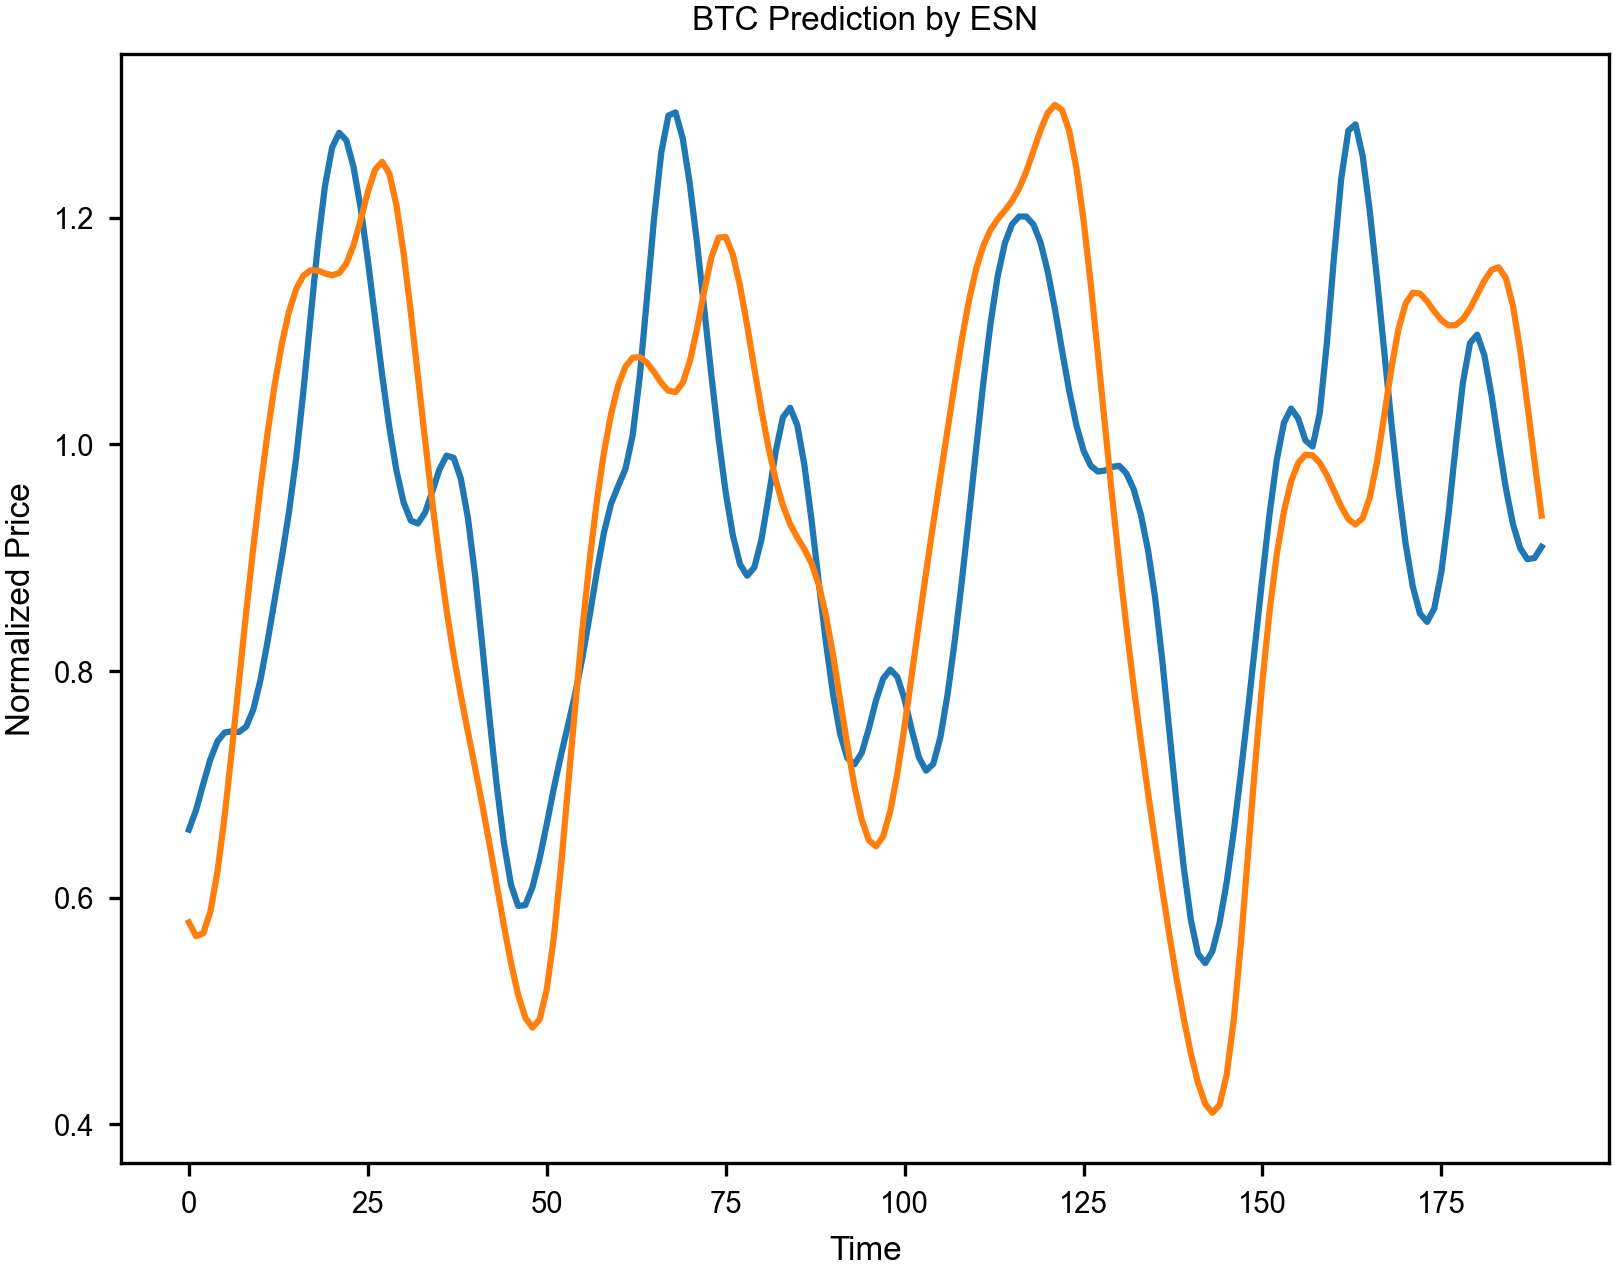

In [17]:
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = task[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")

Pick any reservoir here, we show the performance is comparable to ESN

In [20]:
rep = 10
omega = .1
name = f'MG_omega{omega}_rep{rep}.csv'

In [22]:
nodes = [2,4,6,8,10,12,14,16,18,20,40,50]
ESN_errors = []
ESN_errors_all = []
Quantum_errors = []
Nfading = 10
Ntraining = 790
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau
for r in range(50):
    ESN_errors = []
    for node in nodes: 
        A, B = make_esn_weights(node,input_scale=1.0,spectral_radius=0.95,connectivity=0.1)
        X_ESN= esn_dynamics(task, A, B)
        X_features_ESN = X_ESN[0:K]
        X_train_ESN = X_features_ESN[Nfading : Nfading + Ntraining, :]
        X_test_ESN = X_features_ESN[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
        y_target = task[tau : K + tau]
        y_train = y_target[Nfading : Nfading + Ntraining]
        y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
        W_ESN = fitting_function(X_train_ESN, y_train)
        y_prediction_ESN = predict(X_test_ESN, W_ESN)
        error = nrmse(y_prediction_ESN, y_test)
        ESN_errors.append(error)
    ESN_errors_all.append(ESN_errors)

ESN_errors_all = np.array(ESN_errors_all)
mean_errors = ESN_errors_all.mean(axis=0)
std_errors = ESN_errors_all.std(axis=0)


In [23]:
for node in nodes: 
    df = pd.read_csv(name)
    X_quantum = extract_delayed_single_column(df, 'PQ-10', N=node, repeat_steps=rep)
    X_quantum = add_polynomial_features(X_quantum,nodes=node)
    X_features_quantum = X_quantum[0:K]
    X_train_quantum = X_features_quantum[Nfading : Nfading + Ntraining, :]
    X_test_quantum = X_features_quantum[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    
    W_quantum = fitting_function(X_train_quantum, y_train)
    y_prediction_quantum = predict(X_test_quantum, W_quantum)
    error = nrmse(y_prediction_quantum, y_test)
    Quantum_errors.append(error)
    

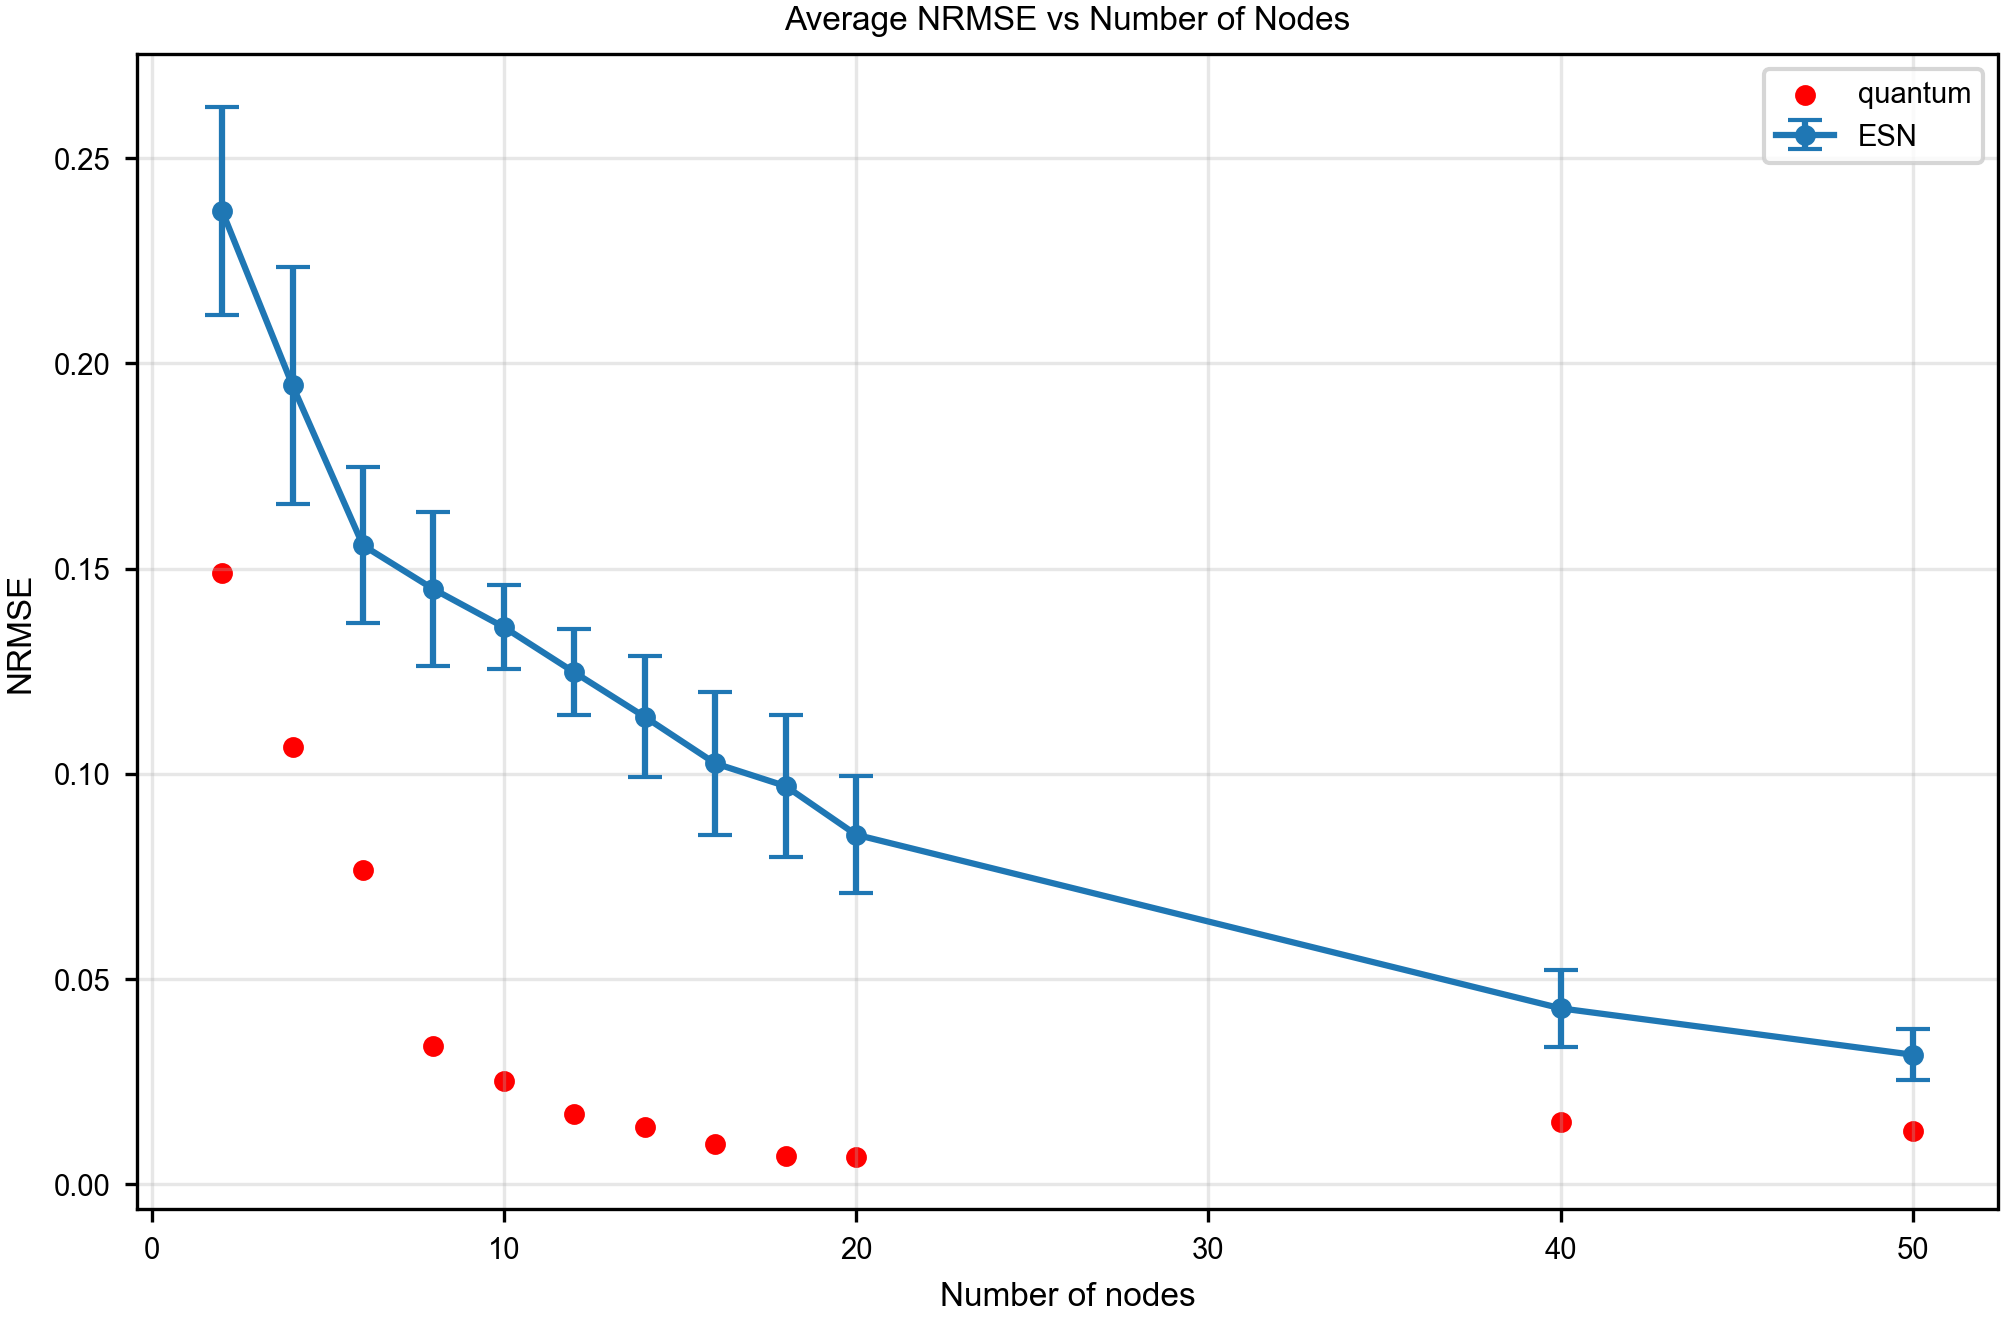

In [24]:
import numpy as np
import matplotlib.pyplot as plt

nodes = np.array(nodes)

plt.figure(figsize=(8, 5))

plt.errorbar(
    nodes,
    mean_errors,
    yerr=std_errors,
    marker='o',
    capsize=4,
    label='ESN'
)

plt.scatter(nodes,Quantum_errors,label='quantum',color='Red')

plt.xlabel("Number of nodes")
plt.ylabel("NRMSE")
plt.title("Average NRMSE vs Number of Nodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Observe how performance changes by omega

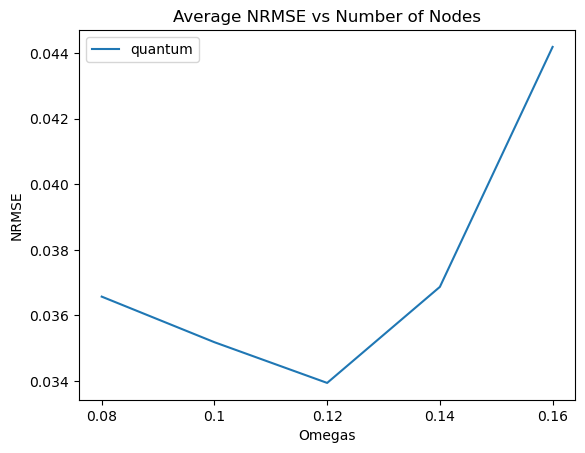

In [17]:
Quantum_errors = []
Nfading = 50
Ntraining = 790
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau
rep = 5
omegas = ['0.08', '0.1', '0.12', '0.14', '0.16']
for omega in omegas: 
    name = f'MG_omega{omega}_rep{rep}.csv'
    df = pd.read_csv(name)
    X_quantum = extract_delayed_single_column(df, 'PQ-10', N=20, repeat_steps=rep)
    
    X_features_quantum = X_quantum[0:K]
    
    X_train_quantum = X_features_quantum[Nfading : Nfading + Ntraining, :]
    X_test_quantum = X_features_quantum[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    
    W_quantum = fitting_function(X_train_quantum, y_train)
    y_prediction_quantum = predict(X_test_quantum, W_quantum)
    error = nrmse(y_prediction_quantum, y_test)
    Quantum_errors.append(error)

plt.plot(omegas, Quantum_errors, label = 'quantum')
plt.xlabel("Omegas")
plt.ylabel("NRMSE")
plt.title("Average NRMSE vs Number of Nodes")
plt.legend()

In [53]:
import pandas as pd
import numpy as np

df = pd.read_csv("X_features08.csv")
X = df.values

(1000, 6)
(1000, 6)
(1000, 6)
(1000, 6)
(1000, 6)


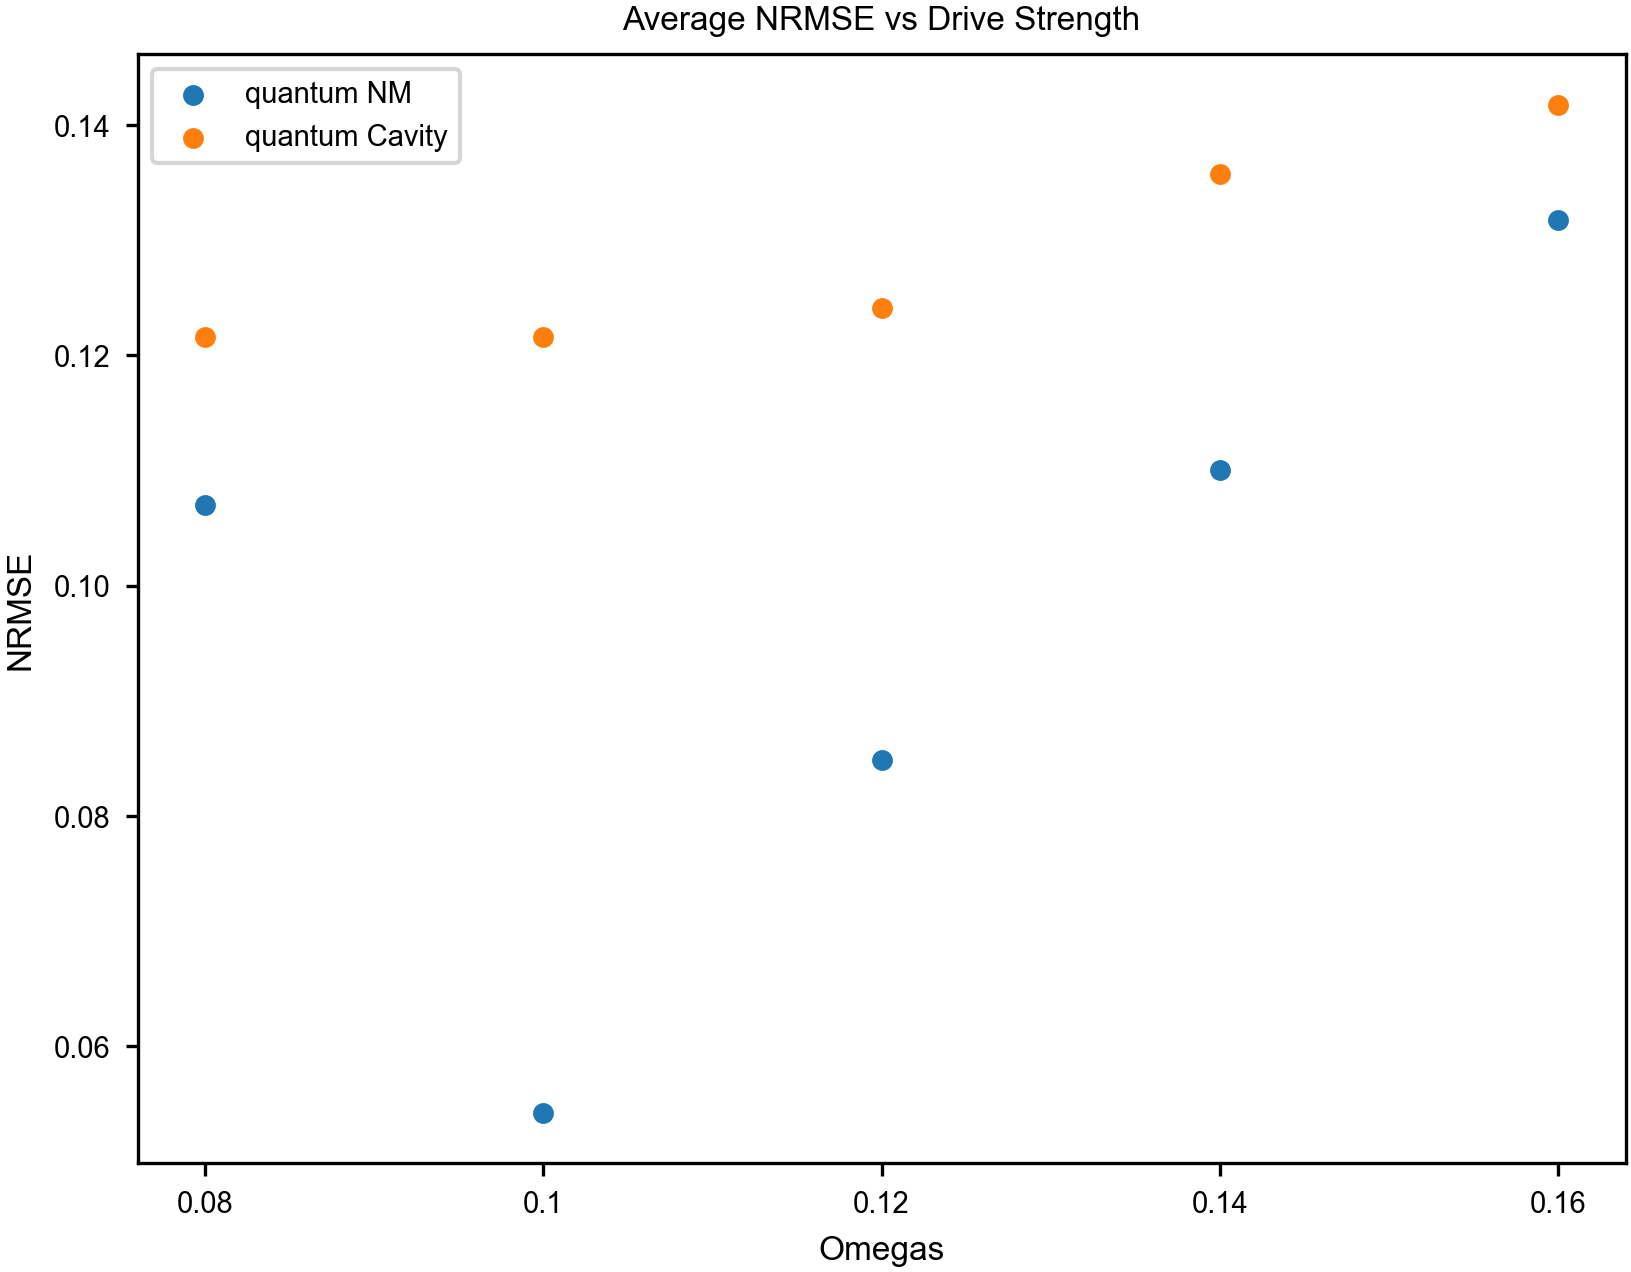

In [28]:
QuantumNM_errors = []
QuantumCavity_errors = []
Nfading = 10
Ntraining = 790
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau
rep = 5
omegas = ['0.08', '0.1', '0.12', '0.14', '0.16']
for omega in omegas: 
    name = f'MG_omega{omega}_rep{rep}.csv'
    df = pd.read_csv(name)
    X_NM = extract_delayed_single_column(df, 'PQ-10', N=6, repeat_steps=rep)
    print(X_NM.shape)
    df = pd.read_csv(f"X_features{omega}_2atoms.csv")
    X_cavity = df.values
    
    X_features_NM = X_NM[0:K]
    X_cavity = X_cavity[0:K]
    
    X_train_NM = X_features_NM[Nfading : Nfading + Ntraining, :]
    X_test_NM = X_features_NM[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

    X_train_cavity = X_cavity[Nfading : Nfading + Ntraining, :]
    X_test_cavity = X_cavity[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    
    W_NM = fitting_function(X_train_NM, y_train)
    y_prediction_NM = predict(X_test_NM, W_NM)
    error = nrmse(y_prediction_NM, y_test)
    QuantumNM_errors.append(error)

    W_cavity = fitting_function(X_train_cavity, y_train)
    y_prediction_cavity = predict(X_test_cavity, W_cavity)
    error = nrmse(y_prediction_cavity, y_test)
    QuantumCavity_errors.append(error)

plt.scatter(omegas, QuantumNM_errors, label = 'quantum NM')
plt.scatter(omegas, QuantumCavity_errors, label = 'quantum Cavity')
plt.xlabel("Omegas")
plt.ylabel("NRMSE")
plt.title("Average NRMSE vs Drive Strength")
plt.legend()

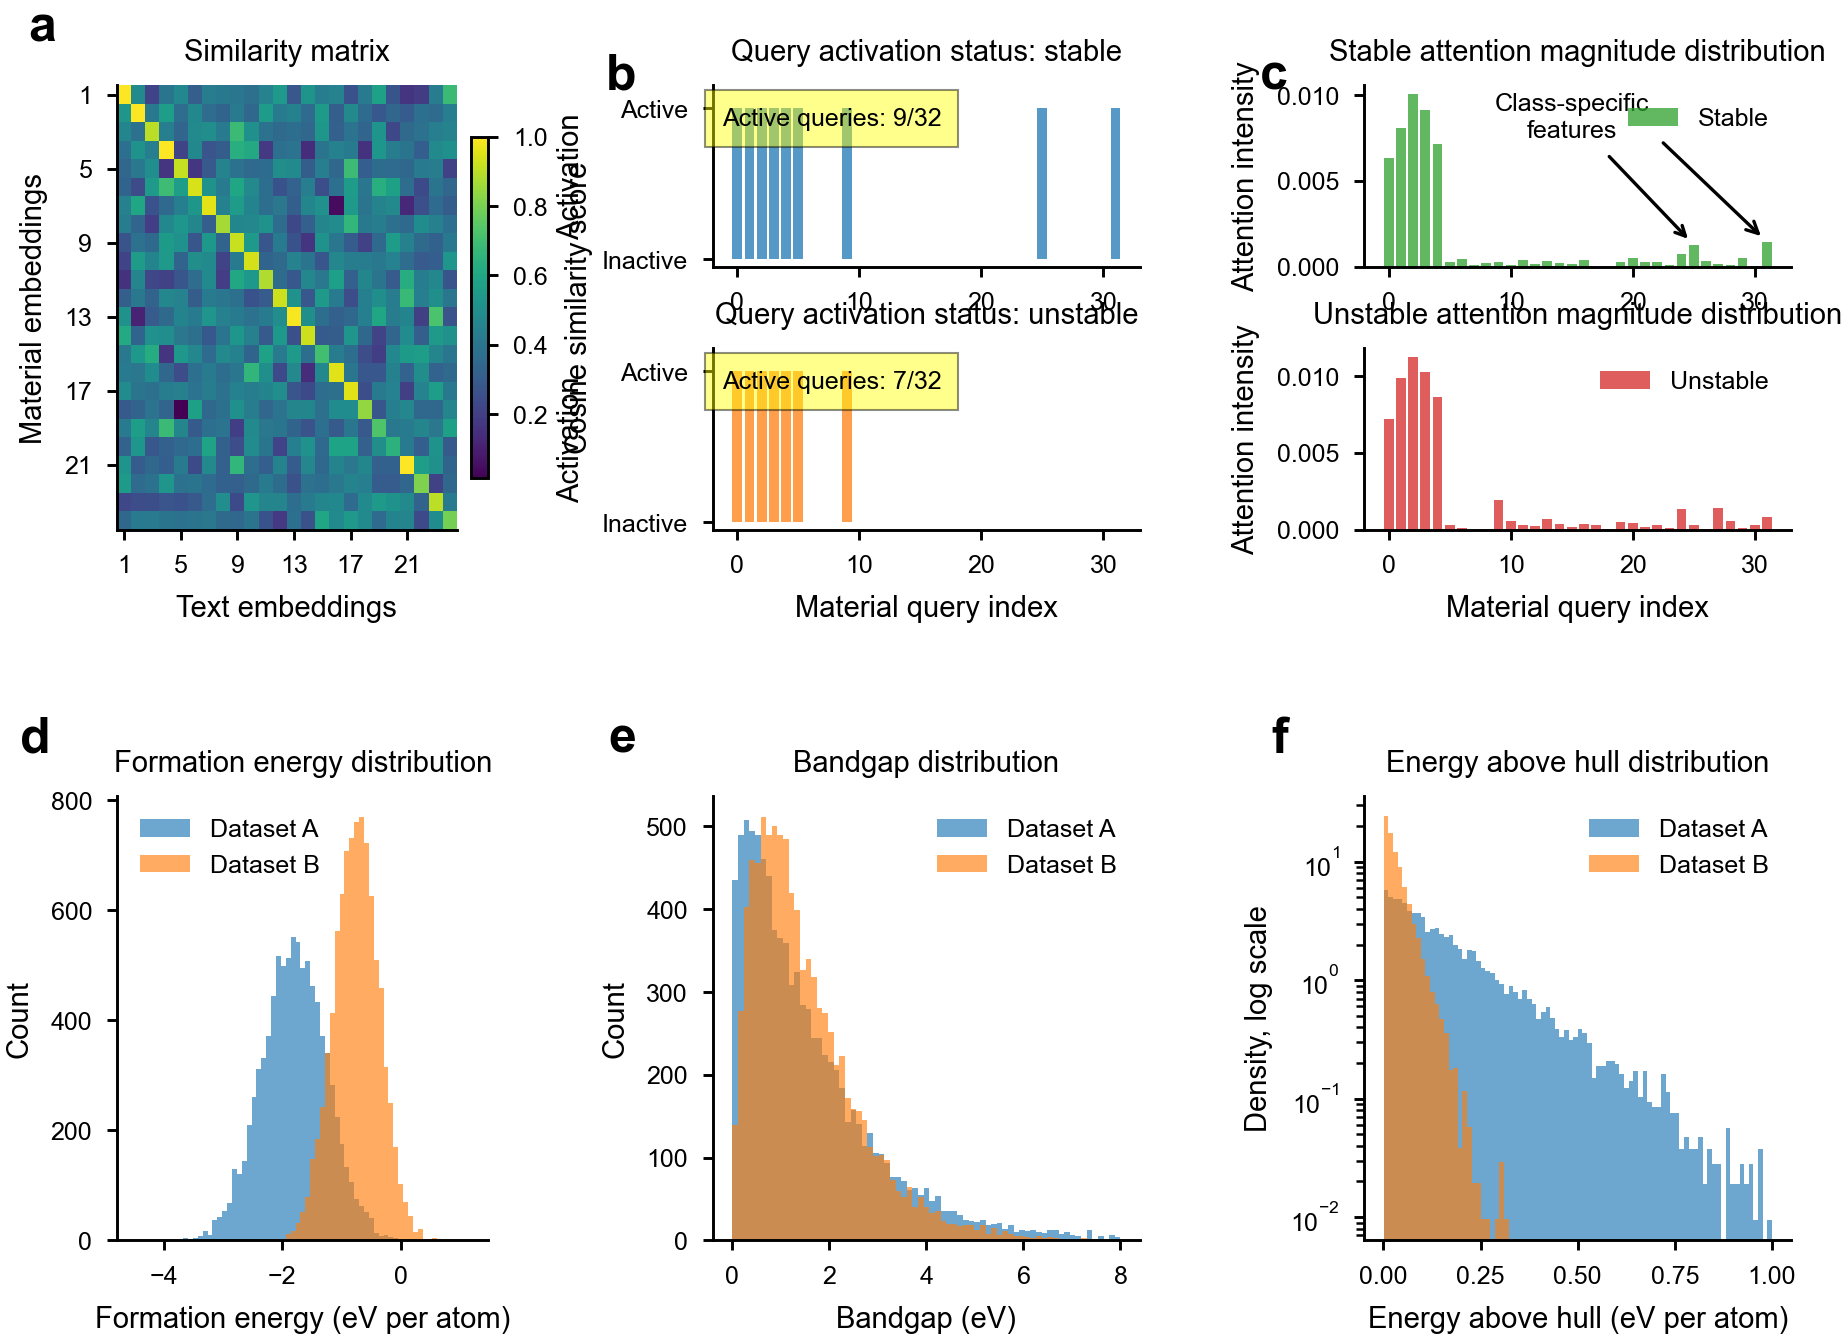

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# 1. Global manuscript style
# =========================
mpl.rcParams.update({
    "font.family": "Arial",        # use "DejaVu Sans" if Arial not available
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,

    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,

    "lines.linewidth": 1.0,
    "lines.markersize": 3,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

np.random.seed(10)

# =========================
# 2. Random example data
# =========================

# Panel a: heatmap
similarity = np.random.normal(0.4, 0.12, size=(24, 24))
similarity += np.eye(24) * 0.5
similarity = np.clip(similarity, 0, 1)

# Panels b/c: activation and attention
query_index = np.arange(32)

stable_active = np.zeros(32)
stable_active[[0, 1, 2, 3, 4, 5, 9, 25, 31]] = 1

unstable_active = np.zeros(32)
unstable_active[[0, 1, 2, 3, 4, 5, 9]] = 1

stable_attention = np.random.gamma(1.0, 0.0003, 32)
stable_attention[[0, 1, 2, 3, 4]] += [0.006, 0.008, 0.010, 0.009, 0.007]
stable_attention[[25, 31]] += [0.0012, 0.0010]

unstable_attention = np.random.gamma(1.0, 0.0003, 32)
unstable_attention[[0, 1, 2, 3, 4]] += [0.007, 0.009, 0.011, 0.010, 0.008]
unstable_attention[9] += 0.0015

# Panels d/e/f: distributions
dataset_A_energy = np.random.normal(-1.8, 0.55, 9000)
dataset_B_energy = np.random.normal(-0.75, 0.38, 9000)

dataset_A_bandgap = np.random.gamma(1.2, 1.35, 9000)
dataset_B_bandgap = np.random.gamma(1.8, 0.85, 9000)

dataset_A_hull = np.random.exponential(0.17, 9000)
dataset_B_hull = np.random.exponential(0.035, 9000)

dataset_A_hull = dataset_A_hull[dataset_A_hull < 1.0]
dataset_B_hull = dataset_B_hull[dataset_B_hull < 1.0]

# =========================
# 3. Figure layout
# =========================

fig = plt.figure(figsize=(7.2, 5.0))

gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1.0, 1.15, 1.15],
    height_ratios=[1.0, 1.0],
    wspace=0.55,
    hspace=0.60
)

ax_a = fig.add_subplot(gs[0, 0])

gs_b = gs[0, 1].subgridspec(2, 1, hspace=0.45)
ax_b1 = fig.add_subplot(gs_b[0, 0])
ax_b2 = fig.add_subplot(gs_b[1, 0])

gs_c = gs[0, 2].subgridspec(2, 1, hspace=0.45)
ax_c1 = fig.add_subplot(gs_c[0, 0])
ax_c2 = fig.add_subplot(gs_c[1, 0])

ax_d = fig.add_subplot(gs[1, 0])
ax_e = fig.add_subplot(gs[1, 1])
ax_f = fig.add_subplot(gs[1, 2])

# =========================
# 4. Panel a: heatmap
# =========================

im = ax_a.imshow(similarity, aspect="auto", cmap="viridis")

ax_a.set_title("Similarity matrix")
ax_a.set_xlabel("Text embeddings")
ax_a.set_ylabel("Material embeddings")

ax_a.set_xticks(np.arange(0, 24, 4))
ax_a.set_yticks(np.arange(0, 24, 4))
ax_a.set_xticklabels(np.arange(1, 25, 4))
ax_a.set_yticklabels(np.arange(1, 25, 4))

cbar = fig.colorbar(im, ax=ax_a, fraction=0.046, pad=0.04)
cbar.set_label("Cosine similarity score")

# =========================
# 5. Panel b: activation bars
# =========================

ax_b1.bar(query_index, stable_active, color="tab:blue", alpha=0.75)
ax_b1.set_title("Query activation status: stable")
ax_b1.set_ylabel("Activation")
ax_b1.set_yticks([0, 1])
ax_b1.set_yticklabels(["Inactive", "Active"])
ax_b1.set_ylim(-0.05, 1.15)

ax_b1.text(
    0.02, 0.78,
    "Active queries: 9/32",
    transform=ax_b1.transAxes,
    fontsize=6,
    bbox=dict(
        facecolor="yellow",
        alpha=0.45,
        edgecolor="black",
        linewidth=0.5
    )
)

ax_b2.bar(query_index, unstable_active, color="tab:orange", alpha=0.75)
ax_b2.set_title("Query activation status: unstable")
ax_b2.set_xlabel("Material query index")
ax_b2.set_ylabel("Activation")
ax_b2.set_yticks([0, 1])
ax_b2.set_yticklabels(["Inactive", "Active"])
ax_b2.set_ylim(-0.05, 1.15)

ax_b2.text(
    0.02, 0.78,
    "Active queries: 7/32",
    transform=ax_b2.transAxes,
    fontsize=6,
    bbox=dict(
        facecolor="yellow",
        alpha=0.45,
        edgecolor="black",
        linewidth=0.5
    )
)

# =========================
# 6. Panel c: attention bars
# =========================

ax_c1.bar(query_index, stable_attention, color="tab:green", alpha=0.75, label="Stable")
ax_c1.set_title("Stable attention magnitude distribution")
ax_c1.set_ylabel("Attention intensity")
ax_c1.legend(frameon=False)

ax_c1.annotate(
    "Class-specific\nfeatures",
    xy=(25, stable_attention[25]),
    xytext=(15, stable_attention.max() * 0.75),
    arrowprops=dict(arrowstyle="->", linewidth=0.8),
    fontsize=6,
    ha="center"
)

ax_c1.annotate(
    "",
    xy=(31, stable_attention[31]),
    xytext=(22, stable_attention.max() * 0.75),
    arrowprops=dict(arrowstyle="->", linewidth=0.8)
)

ax_c2.bar(query_index, unstable_attention, color="tab:red", alpha=0.75, label="Unstable")
ax_c2.set_title("Unstable attention magnitude distribution")
ax_c2.set_xlabel("Material query index")
ax_c2.set_ylabel("Attention intensity")
ax_c2.legend(frameon=False)

# =========================
# 7. Panel d/e/f: histograms
# =========================

bins_energy = np.linspace(-4.5, 1.2, 70)

ax_d.hist(
    dataset_A_energy,
    bins=bins_energy,
    alpha=0.65,
    color="tab:blue",
    label="Dataset A"
)

ax_d.hist(
    dataset_B_energy,
    bins=bins_energy,
    alpha=0.65,
    color="tab:orange",
    label="Dataset B"
)

ax_d.set_title("Formation energy distribution")
ax_d.set_xlabel("Formation energy (eV per atom)")
ax_d.set_ylabel("Count")
ax_d.legend(frameon=False)


bins_bandgap = np.linspace(0, 8, 70)

ax_e.hist(
    dataset_A_bandgap,
    bins=bins_bandgap,
    alpha=0.65,
    color="tab:blue",
    label="Dataset A"
)

ax_e.hist(
    dataset_B_bandgap,
    bins=bins_bandgap,
    alpha=0.65,
    color="tab:orange",
    label="Dataset B"
)

ax_e.set_title("Bandgap distribution")
ax_e.set_xlabel("Bandgap (eV)")
ax_e.set_ylabel("Count")
ax_e.legend(frameon=False)


bins_hull = np.linspace(0.001, 1.0, 85)

ax_f.hist(
    dataset_A_hull,
    bins=bins_hull,
    alpha=0.65,
    density=True,
    color="tab:blue",
    label="Dataset A"
)

ax_f.hist(
    dataset_B_hull,
    bins=bins_hull,
    alpha=0.65,
    density=True,
    color="tab:orange",
    label="Dataset B"
)

ax_f.set_yscale("log")
ax_f.set_title("Energy above hull distribution")
ax_f.set_xlabel("Energy above hull (eV per atom)")
ax_f.set_ylabel("Density, log scale")
ax_f.legend(frameon=False)

# =========================
# 8. Panel labels and cleanup
# =========================

panel_axes = [ax_a, ax_b1, ax_c1, ax_d, ax_e, ax_f]
panel_labels = ["a", "b", "c", "d", "e", "f"]

for label, ax in zip(panel_labels, panel_axes):
    ax.text(
        -0.18, 1.18,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="right"
    )

for ax in [ax_a, ax_b1, ax_b2, ax_c1, ax_c2, ax_d, ax_e, ax_f]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =========================
# 9. Save figure
# =========================

#plt.savefig("random_nature_style_multipanel.pdf")
#plt.savefig("random_nature_style_multipanel.png", dpi=300)
plt.show()